# Data Visualization

## Heatmap

[[66 43 70 75 21 81 84 21 41 22]
 [51 98 34 99  7  2 11 38 78 44]
 [19 29 14 56 57  5 46 32 13 48]
 [54 33 67  7 20 56 27 16 73 54]
 [29 52 88 72 76 77 26 37 81 28]
 [15 26  7 14 27 62 29 60 30 79]
 [19 53 27 27 99 82 42 49 93 75]
 [61 78  9 82 66 88 88 91 38 26]
 [11  9 13 72 77 17 43 90 55 27]
 [18 61 28 99 82 61 56 64 36 87]]


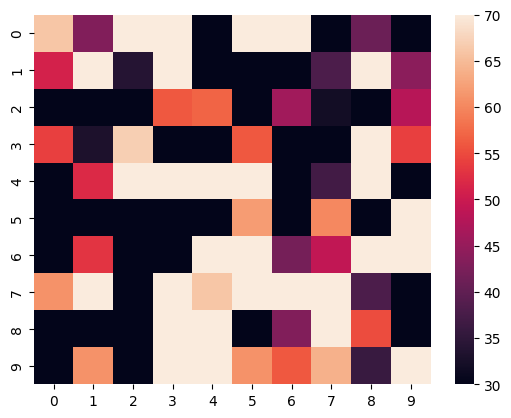

In [1]:
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

data = np.random.randint(low=1, high=100, size=(10,10))
print(data)

hm = sns.heatmap(data, vmin=30, vmax=70)

plt.show()

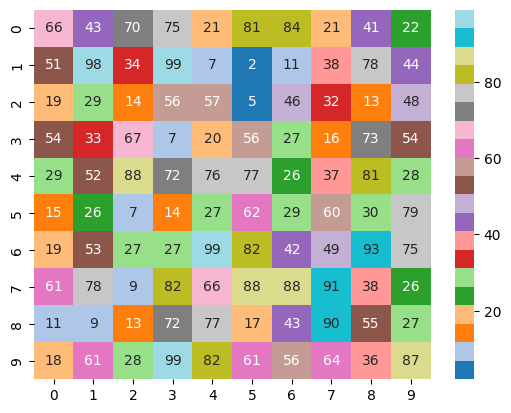

In [6]:
hm = sns.heatmap(data, cmap='tab20', annot=True)

plt.show()

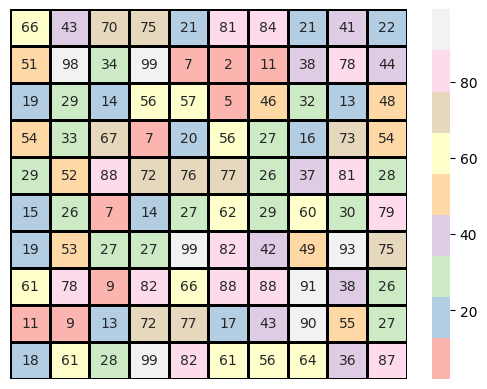

In [7]:
hm = sns.heatmap(data, cmap='Pastel1', annot=True, linewidths=1, linecolor='black', xticklabels=False, yticklabels=False) # also cbar =False to remove cbar

plt.show()

          a         b         c         d         e
0  0.810239  0.373741  0.163847  0.713861  0.885125
1  0.208453  0.507839  0.603071  0.429165  0.948993
2  0.148653  0.306703  0.184087  0.581576  0.059294
3  0.265612  0.422767  0.490674  0.263923  0.392860
4  0.576678  0.371861  0.471093  0.684980  0.644861


<Axes: >

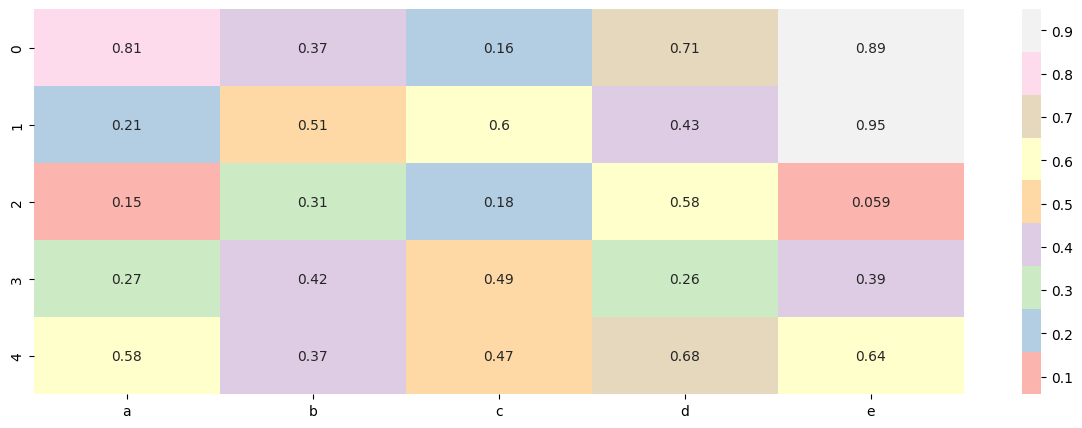

In [15]:
from IPython.core.pylabtools import figsize
import pandas as pd

plt.figure(figsize=(15,5))
df = pd.DataFrame(np.random.random((5,5)),
                columns=['a','b','c','d','e'])
print(df)

sns.heatmap(df, annot=True, cmap='Pastel1')

## Box Plot

In [24]:
df = pd.read_csv('../../../Ch1/Datasets/auto-mpg.csv')

df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


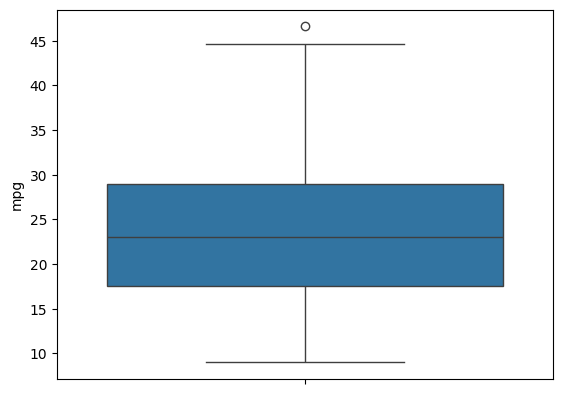

In [17]:
sns.boxplot(y=df['mpg'])
plt.show()

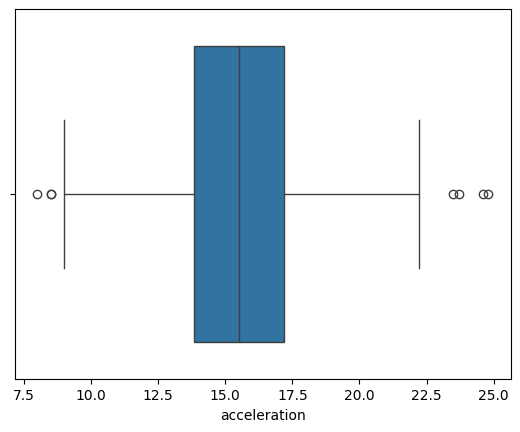

In [25]:
sns.boxplot(x='acceleration', data=df)
plt.show()

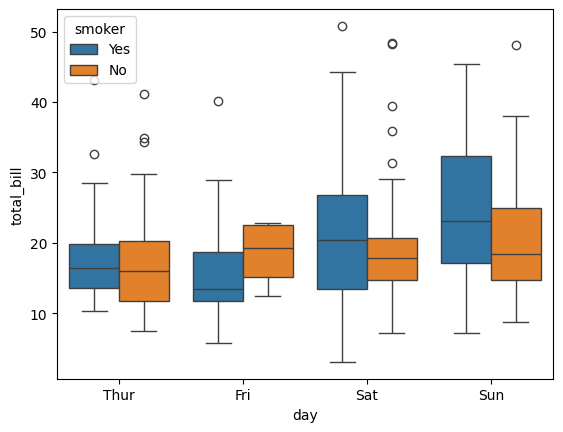

In [21]:
df =  sns.load_dataset('tips')
sns.boxplot(x='day',y='total_bill', hue='smoker', data=df)
plt.show()

In [5]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px
import plotly.io as pio 
pio.renderers.default = 'browser'
data = {
    "Marks":[40,45,50,55,60,65,70,75,80,85],
    "Gender":["Male","Female","Male","Female","Male",
              "Female","Male","Female","Male","Female"]
}
 
df = pd.DataFrame(data)
fig = px.histogram(
    df,
    x="Gender",
    y='Marks',
    nbins=5,
    color="Gender",
    histfunc="sum",
    pattern_shape="Gender",
    text_auto=True,
    color_discrete_map={"Male":"blue","Female":"pink"},
#     color_discrete_sequence=["blue","pink"] #Optional
)

fig.show()

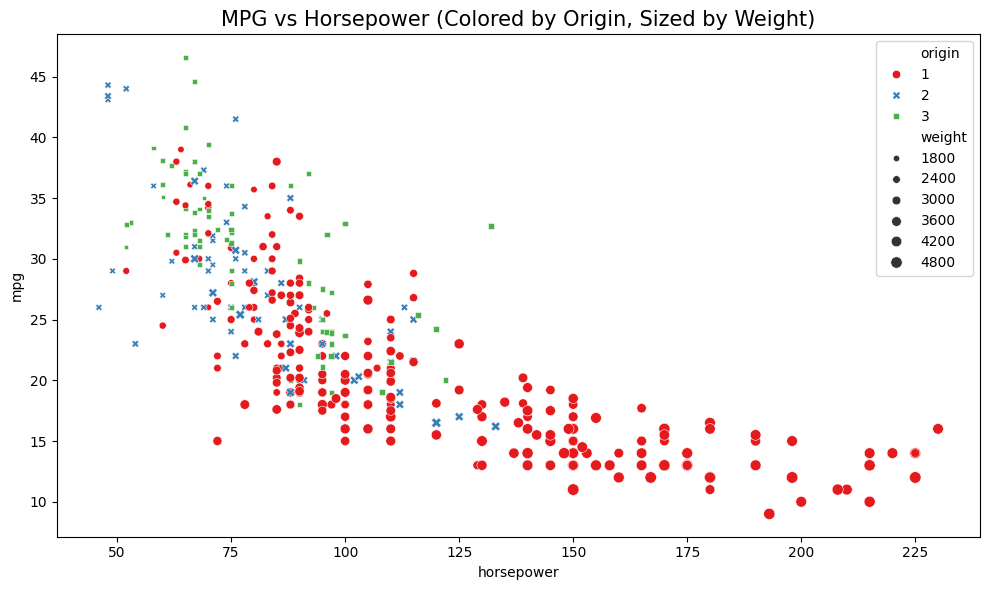

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load and clean the data
df = pd.read_csv('../../../Ch1/Datasets/auto-mpg.csv')
# Convert horsepower to numeric and handle non-numeric '?' values

df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
#In its raw form, the horsepower column contains the character '?' for missing values. 
#Because of this single string character, Pandas loads the entire column as an object (text) rather than numbers.

#What your code does:
#By using pd.to_numeric(..., errors='coerce'), you are telling Pandas:

#Convert everything in the column to a number (float).

#errors='coerce': If you encounter something that isn't a number (like '?'), don't crash. 
#Instead, turn it into NaN (Not a Number/null).
df = df.dropna(subset=['horsepower'])

# 2. Create the scatter plot
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='horsepower',    # Horizontal axis
    y='mpg',           # Vertical axis
    hue='origin',      # Color by origin
    style='origin',    # Different markers by origin
    size='weight',     # Size of dots based on car weight
    palette='Set1',    # Color palette
)

# 3. Final Styling
plt.title('MPG vs Horsepower (Colored by Origin, Sized by Weight)', fontsize=15)
plt.tight_layout()

plt.show()

## Networksx

types: 
1. directed
2. undirected

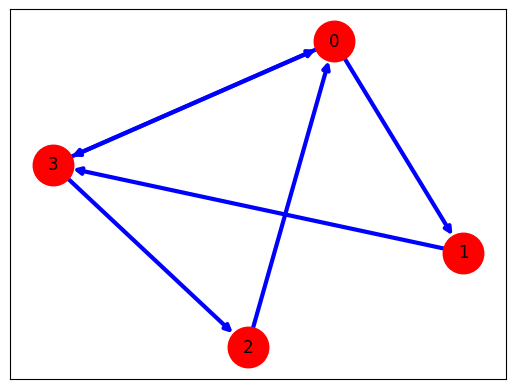

In [11]:
import networkx as nx
import matplotlib.pyplot as plt

G=nx.DiGraph()
 # for undirected G= nx.graph
G.add_nodes_from(range(4))
l=[[0,1,0,1],[0,0,0,1],[1,0,0,0],[1,0,1,0]]

for i in range(4):
    for j in range(4):
        if l[i][j]==1:
            G.add_edge(i,j)

nx.draw_networkx(G,node_size=850,node_color='red',edge_color='blue',width=3)
plt.show()

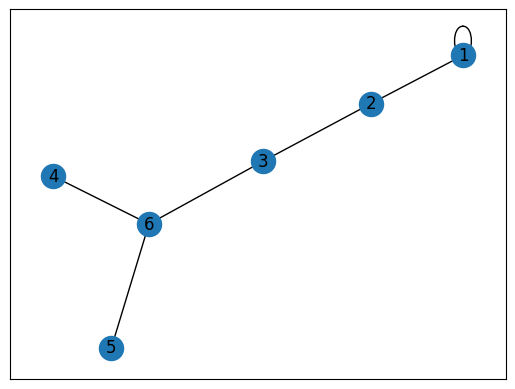

In [14]:
G = nx.Graph()

G.add_node(1)
G.add_nodes_from([2,3])
G.add_nodes_from(range(4,7))

G.add_edge(1, 2)
G.add_edge(1,1)
G.add_edges_from([(2,3),(3,6),(4,6),(5,6)])

nx.draw_networkx(G, with_labels=True)
plt.show()

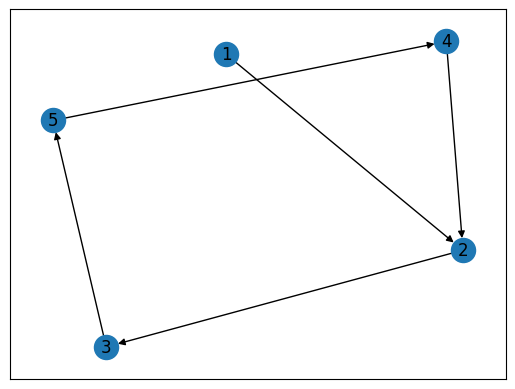

In [19]:
import networkx as nx 
import matplotlib.pyplot as plt 

g = nx.DiGraph()

g.add_nodes_from([1,2,3,4,5])

g.add_edge(1,2)
g.add_edges_from([(4,2), (3,5), (2,3), (5,4)])

nx.draw_networkx(g)

## SuperVised Learning

